In [27]:
import sys
sys.path.append("..")
from utils.utils import * 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from ucimlrepo import fetch_ucirepo 

## Data load

In [28]:
concrete_compressive_strength = fetch_ucirepo(id=165) 
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets.squeeze()

## Data inspection

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
dtype: int64

np.int64(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 64.5 KB


None

<class 'pandas.core.series.Series'>
RangeIndex: 1030 entries, 0 to 1029
Series name: Concrete compressive strength
Non-Null Count  Dtype  
--------------  -----  
1030 non-null   float64
dtypes: float64(1)
memory usage: 8.2 KB


None

Cement                0.497832
Blast Furnace Slag    0.134829
Fly Ash              -0.105755
Water                -0.289633
Superplasticizer      0.366079
Coarse Aggregate     -0.164935
Fine Aggregate       -0.167241
Age                   0.328873
Name: target, dtype: float64

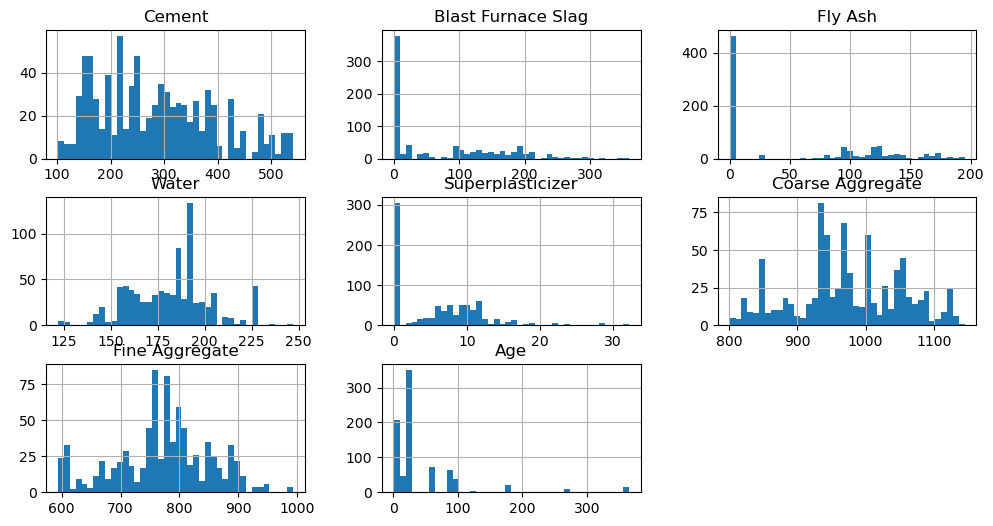

In [29]:
display(X.isnull().sum())
display(y.isnull().sum())
display(X.info())
display(y.info())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.hist(figsize=(12,6), bins=40)

data_corr = X.copy()
data_corr["target"] = y
corr_with_y = data_corr.corr()["target"].drop("target")
display(corr_with_y)

## Preprocessing

In [30]:
num_pipeline = make_pipeline(
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_train.columns)
])

## Model

In [31]:
reg = make_pipeline(
    preprocessing,
    LinearRegression()
)

reg.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluation

Test R2: 0.627553179231485
Test MSE: 95.97094009110683
Test RMSE: 9.79647590162436
Test MAE: 7.745559243921434


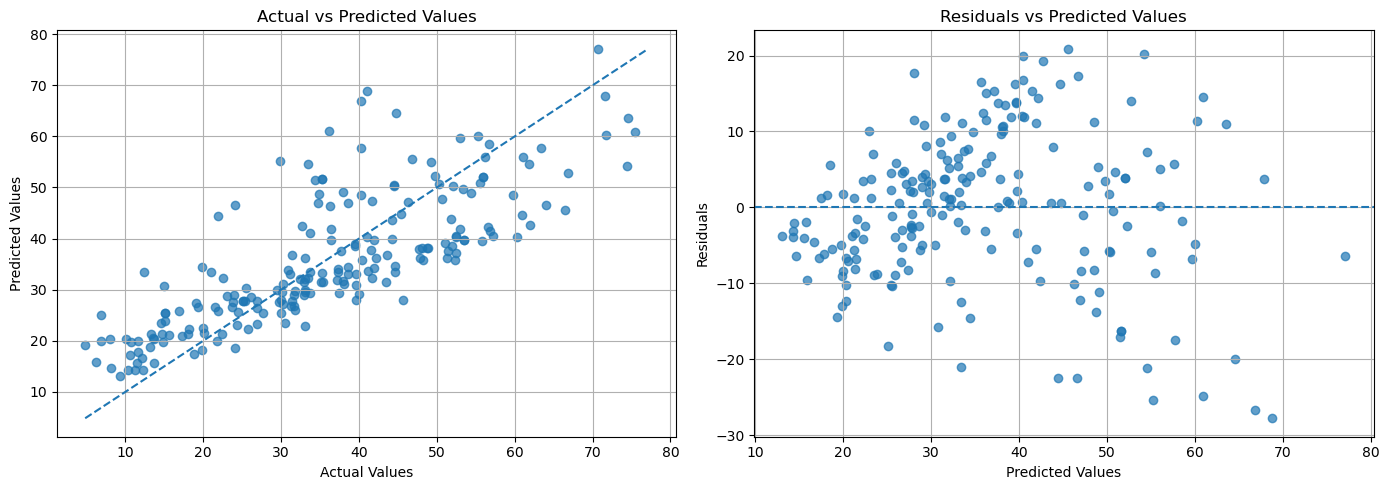

In [32]:
evaluate_regression(reg, X_test, y_test)